### Imports and Constants

In [1]:
import sys
sys.path.append('../')

from gam_rs_utils.utils import *
from method_scripts.results import Results

In [2]:
SUPPORT_SET_METRICS = [Metrics.inverse_IoU, Metrics.euclidean_distance, Metrics.inverse_cosine_similarity]
LOSS_METRICS = ['accuracy', 'logistic']
LOGIT_METRICS = [Metrics.compute_logit_variance, Metrics.compute_logit_pairwise_distance]
PREDICTION_METRICS = [Metrics.hamming_distance]

def collate_datasets_results():
    all_datasets_results = {}
    for dn in DATASET_NAMES:
        runs = list()
        runs_paths = os.listdir(f"../results/{dn}/method_results")
        runs_paths.sort()
        for fn in runs_paths:
            result = Results.load_result(f"../results/{dn}/method_results/{fn}")
            runs.append(result.to_dataframe_row())
        all_datasets_results[dn] = pd.concat(runs, axis=0, ignore_index=True)
    return all_datasets_results

def compute_feature_specific_metrics(new_cols, bin_X, bin_header, w_rset, n_samples):
    # compute feature-specific metrics
    new_cols['feature_to_variable_importance'] = Plotter.get_variable_importance(
        bin_X,
        w_rset[:, 1:],
        np.array(bin_header[1:]),
        True
    )

    # compute variable importance for each feature
    feature_indices = ModelUtils.get_feature_indices(bin_header)
    feature_widths = ModelUtils.get_feature_widths(bin_header)

    feature_logit_difference = defaultdict(list)
    feature_shape_difference = defaultdict(list)
    for feature, indices in feature_indices.items():
        indices = np.array(indices)
        feature_logit_difference[feature].append(Metrics.average_pairwise_diversity(
            w_rset[:, indices], 
            Metrics.logit_difference, 
            limit=n_samples, 
            X=bin_X[:, indices]
        ))
        feature_shape_difference[feature].append(Metrics.average_pairwise_diversity(
            w_rset[:, indices], 
            Metrics.shape_difference, 
            limit=n_samples, 
            X=feature_widths[feature]
        ))
    new_cols['feature_logit_difference'].append(feature_logit_difference)
    new_cols['feature_shape_difference'].append(feature_shape_difference)

def populate_datasets_results(all_datasets_results, n_samples):
    # do hamming, model count, 
    for dn, df in all_datasets_results.items():
        new_cols = defaultdict(list)
        for i, row in df.iterrows():
            # load rashomon set for this run
            w_rset = row['w_rset']
            idx = np.random.choice(w_rset.shape[0], size=n_samples, replace=False)
            w_rset = w_rset[idx]
            w_opt = row['w_opt']
            l0 = row['l0']
            l2 = row['l2']
            method_type = row['method_type']

            # load dataset used for this run
            dataset = Results.load_dataset(f"../results/{dn}", {'l0': l0, 'l2': l2})
            bin_X = dataset['bin_X']
            y = dataset['y']
            bin_header = dataset['bin_header']
            cum_header = dataset['cum_header']

            # compute diversity metrics on the support set
            for metric in SUPPORT_SET_METRICS:
                average_diversity = Metrics.average_pairwise_diversity(w_rset, metric, limit=n_samples)
                new_cols[metric.__name__].append(average_diversity)
            
            # compute loss values
            for metric in LOSS_METRICS:
                losses, opt_loss = ModelUtils.get_loss(bin_X, y, w_rset, loss_type=metric, w_opt=w_opt, l2=l2)
                new_cols[metric].append(losses)
                new_cols[metric + '_opt'].append(opt_loss)

            # compute logit metrics
            logits = bin_X @ w_rset.T
            for metric in LOGIT_METRICS:
                new_cols[metric.__name__].append(metric(logits))

            # compute prediction metrics
            predictions = ModelUtils.get_predictions(bin_X, w_rset)
            for metric in PREDICTION_METRICS:
                average_diversity = Metrics.average_pairwise_diversity(predictions.T, metric, limit=n_samples)
                new_cols[metric.__name__].append(average_diversity)

            # compute feature-specific metrics
            compute_feature_specific_metrics(new_cols, bin_X, bin_header, w_rset, n_samples)
            print(new_cols)


        # add new_cols to df
        for key, value in new_cols.items():
            df[key] = value

### Compute All Metrics

In [15]:
n_samples = 100
all_datasets_results = collate_datasets_results()

In [16]:
populate_datasets_results(all_datasets_results, n_samples)

loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
defaultdict(<class 'list'>, {'inverse_IoU': [(0.0, array([0., 0.]))], 'euclidean_distance': [(56.23548391239539, array([56.23548391, 56.23548391]))], 'inverse_cosine_similarity': [(0.35620329044439175, array([0.35620329, 0.35620329]))], 'accuracy': [[0.099535500995355, 0.0999778809997788, 0.09798717097987171, 0.09887193098871931, 0.10727715107277151, 0.11037381110373812, 0.10307454103074541, 0.0990931209909312, 0.09666003096660031, 0.09842955098429551, 0.1041804910418049, 0.0982083609820836, 0.10064145100641451, 0.0990931209909312, 0.11037381110373812, 0.1032957310329573, 0.10042026100420261, 0.1112585711125857, 0.09931431099314311, 0.10086264100862641, 0.10506525105065251, 0.0999778809997788, 0.10174740101747401, 0.10351692103516921, 0.09599646095996461, 0.10108383101083832, 0.1032957310329573, 0.09776598097765982, 0.11015262110152621, 0.09798717097987171, 0.10019907100199071, 0.0982083609820836, 0.1079407210794072, 0.09666003

KeyboardInterrupt: 

In [39]:
with open(f'all_datasets_results.pkl', 'wb') as f:
    pickle.dump(all_datasets_results, f)

### Get Plotting Functions

In [8]:
with open(f'../all_datasets_results.pkl', 'rb') as f:
    all_datasets_results = pickle.load(f)
    
def get_label(row):
    if row['method_type'] == MethodType.SWAPPING:
        return f"{row['method_type'].value} {row['k']}"
    elif row['method_type'] == MethodType.ELLIPSOID:
        label = f"{row['method_type'].value} {row['sampling']}"
        if row['distance_metric']:
            label += f" ({row['distance_metric']})"
        return label
    elif row['method_type'] == MethodType.MCMC:
        return f"{row['method_type'].value} {row['proposal_function']}, sample {row['sample_from_rset']}"
    else:
        return row['method_type'].value

want_to_plot = [
    'ellipsoid surface (euclidean)',
    # 'mcmc random, sample 20.0',
    'mcmc correlation_swap, sample 20.0',
    'mcmc random_swap, sample 20.0',
    'mcmc same_feature_swap, sample 20.0',
    'mcmc multi_swap, sample 20.0',
    # 'mcmc random, sample 0.0',
    # 'mcmc correlation_swap, sample 0.0',
    # 'mcmc random_swap, sample 0.0',
    # 'mcmc same_feature_swap, sample 0.0'
    'swapping 3.0',
]
for dn, df in all_datasets_results.items():
    for i, row in df.iterrows():
        if want_to_plot and get_label(row) not in want_to_plot:
            # print(f"dropping {get_label(row)}")
            df.drop(i, inplace=True)

# sort rows by get_label(row)
for dn, df in all_datasets_results.items():
    df['_temp_label'] = df.apply(get_label, axis=1)
    df = df.sort_values(by='_temp_label')
    df = df.drop(columns=['_temp_label'])
    all_datasets_results[dn] = df

In [4]:
all_datasets_results['diabetes']

,method_type,dataset,n_estimators,n_support_set,n_samples,w_rset,w_opt,rset_bound,runtime,l0,...,inverse_IoU,euclidean_distance,inverse_cosine_similarity,accuracy,accuracy_opt,logistic,logistic_opt,compute_logit_variance,compute_logit_pairwise_distance,hamming_distance
5,MethodType.ELLIPSOID,diabetes,200,45,1000,"[[0.24031446904147835, -1.779664231411771, -1....","[-0.13863964852662403, -0.23069309071607502, -...",0.45,3.941946,0.001,...,"(0.0, [0.0, 0.0])","(68.5484179847429, [68.5484179847429, 68.54841...","(0.3922328906363837, [0.3922328906363837, 0.39...","[0.19010416666666666, 0.1875, 0.1796875, 0.175...",0.165365,"[0.43660687680460664, 0.4220542387159585, 0.43...",0.374841,"(10.160525313901152, [7.07521185205103, 13.508...","(36.02154708000829, [8.98909846773501, 113.892...","(93.31838383838384, [93.31838383838384, 93.318..."
12,MethodType.MCMC,diabetes,200,45,1066,"[[-0.1351864650542687, -0.22728749488344208, -...","[-0.1351864650542687, -0.22728749488344208, -0...",0.45,108.934325,0.001,...,"(0.05667852521350851, [0.05667852521350851, 0....","(47.64874283023736, [47.64874283023736, 47.648...","(0.5419509350608521, [0.5419509350608521, 0.54...","[0.23307291666666666, 0.2109375, 0.20572916666...",0.165365,"[0.4458224722090198, 0.4474017649389243, 0.436...",0.374787,"(5.577633393199956, [3.4219252817258585, 11.34...","(29.41199367558462, [9.322344929080245, 67.988...","(110.12363636363636, [110.12363636363636, 110...."
13,MethodType.MCMC,diabetes,200,45,1067,"[[-0.1351864650542687, -0.22728749488344208, -...","[-0.1351864650542687, -0.22728749488344208, -0...",0.45,108.191871,0.001,...,"(0.03994650926807578, [0.03994650926807578, 0....","(46.92548249855042, [46.92548249855042, 46.925...","(0.5556796595136007, [0.5556796595136007, 0.55...","[0.2109375, 0.20703125, 0.21875, 0.20442708333...",0.165365,"[0.44619562169280436, 0.44353599931978077, 0.4...",0.374787,"(5.421961871372156, [3.4342030706750872, 10.09...","(29.085959606153416, [9.480178738131912, 66.80...","(110.03696969696969, [110.03696969696969, 110...."
16,MethodType.MCMC,diabetes,200,45,292,"[[-0.1351864650542687, -0.22728749488344208, -...","[-0.1351864650542687, -0.22728749488344208, -0...",0.45,62.191421,0.001,...,"(0.002241216950380302, [0.002241216950380302, ...","(40.06634858152505, [40.06634858152505, 40.066...","(0.49019268976631003, [0.49019268976631003, 0....","[0.1953125, 0.20052083333333334, 0.21484375, 0...",0.165365,"[0.4453761814931602, 0.44856520190449073, 0.44...",0.374787,"(4.475806760575739, [3.1513397267415755, 8.119...","(25.762120278280314, [6.934204947919061, 63.22...","(97.73636363636363, [97.73636363636363, 97.736..."
21,MethodType.SWAPPING,diabetes,200,27,11163,"[[10.32238347049651, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[6.512665275757921, -0.5657085406462053, -0.56...",0.45,560.963173,0.001,...,"(0.028944502997921742, [0.028944502997921742, ...","(44.20834841993371, [44.20834841993371, 44.208...","(0.1017686640414335, [0.1017686640414335, 0.10...","[0.16666666666666666, 0.15755208333333334, 0.1...",0.166667,"[0.4410119604566345, 0.4308971894818901, 0.443...",0.416660,"(7.334725901827017, [6.852904215842206, 7.7897...","(30.69934434564425, [3.684574806161975, 87.828...","(29.54060606060606, [29.54060606060606, 29.540..."


In [5]:
def show_loss_distributions(all_datasets_results, dn, loss_type):
    df = all_datasets_results[dn]
    plotter = MultiPlotter(title=f"{dn} - {loss_type} Loss Distributions")
    for i, row in df.iterrows():
        losses = row[loss_type]
        opt_loss = row[loss_type + '_opt']
        plotter.add_distribution(losses, get_label(row), opt_loss)
    plotter.plot_distributions()

def get_bar_plot(all_datasets_results, metric):
    plotter = MultiPlotter(title=f"{metric} Bar Plot")
    for dname, df in all_datasets_results.items():
        labels = [get_label(row) for _, row in df.iterrows()]
        list_of_mean_and_cis = df[metric].to_list()
        if metric in PREDICTION_METRICS:
            list_of_mean_and_cis = [Metrics.get_mean_and_ci(distribution) for distribution in list_of_mean_and_cis]
        if metric == 'runtime':
            list_of_mean_and_cis = [(r, (r, r)) for r in list_of_mean_and_cis]
        plotter.add_bar(list_of_mean_and_cis, dname, labels)
    fig = plotter.plot_bar_charts()
    return fig

def get_gam(all_datasets_results, dname, n_samples=50):
    plotter = MultiPlotter(title=f"GAM Shape Functions")
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        dataset = Results.load_dataset(f"../results/{dname}", {'l0': 0.001, 'l2': 0.001})
        plotter.add_shape_function(np.array(dataset['bin_header'][1:]), row['w_rset'][:n_samples, 1:], get_label(row))
    fig = plotter.plot_shape_functions()
    return fig

def get_variable_importance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    plotter = MultiPlotter(title=f"Variable Importance Distributions")
    for i, row in df.iterrows():
        plotter.add_variable_importance_distribution(row['feature_to_vi'], row['method'])
    fig = plotter.plot_variable_importance_distributions()
    return fig

def get_model_reliance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    
    plotter = MultiPlotter(title=f"Model Reliance for {dname}")
    for i, row in df.iterrows():
        plotter.add_model_reliance(row['feature_to_vi'], row['method'])
    fig = plotter.plot_model_reliance_violin_plots()
    return fig

def get_feature_to_shape_diversity(all_dataset_results, dname, metric):
    df = all_dataset_results[dname]

    plotter = MultiPlotter(title=f"{metric} for {dname}")
    for i, row in df.iterrows():
        plotter.add_shape_diversity(row[metric], row['method'])
    fig = plotter.plot_shape_diversity()
    return fig

def show_swapping_percentages(all_dataset_results, dname):
    df = all_dataset_results[dname]
    collated_swapping_percentages = []
    for i, row in df.iterrows():
        if row['method'].startswith("swapping"):
            collated_swapping_percentages.append(row['swapping_percentages'])

    swapping_methods = [m for m in methods if m.startswith("swapping")]
    plt.bar(swapping_methods, [np.average(p) for p in collated_swapping_percentages])
    plt.xticks(rotation=45)
    plt.title(f"Swapping Percentages")
    plt.tight_layout()
    plt.show()

    for sm, p in zip(swapping_methods, collated_swapping_percentages):
        plt.hist(p, bins=30)
        plt.title(f"{sm} - Swapping Percentages")
        plt.tight_layout()
        plt.show()

def get_table_results(all_dataset_results):
    details = ['dataset', 'method', 'runtime']
    distribution_metrics = ['accuracy', 'logistic']
    metrics = ['inverse_IoU', 'euclidean_distance', 'inverse_cosine_similarity'] #'compute_logit_variance', 'compute_logit_pairwise_distance', 'hamming']
    # feature_based_metrics = ['feature_to_shape_differences', 'feature_to_shape_diversities']

    combined_df = pd.DataFrame()
    for dname, df in all_dataset_results.items():
        df['method'] = [get_label(row) for _, row in df.iterrows()]
        df = df[details + distribution_metrics + metrics].copy()
        df['runtime'] = df['runtime'].apply(lambda v: round(v, 3))
        df[distribution_metrics] = df[distribution_metrics].applymap(lambda v: round(np.average(v), 3))
        df[metrics] = df[metrics].applymap(lambda v: round(v[0], 3))
        combined_df = pd.concat([combined_df, df], ignore_index=True)
    return combined_df

### Visualizations

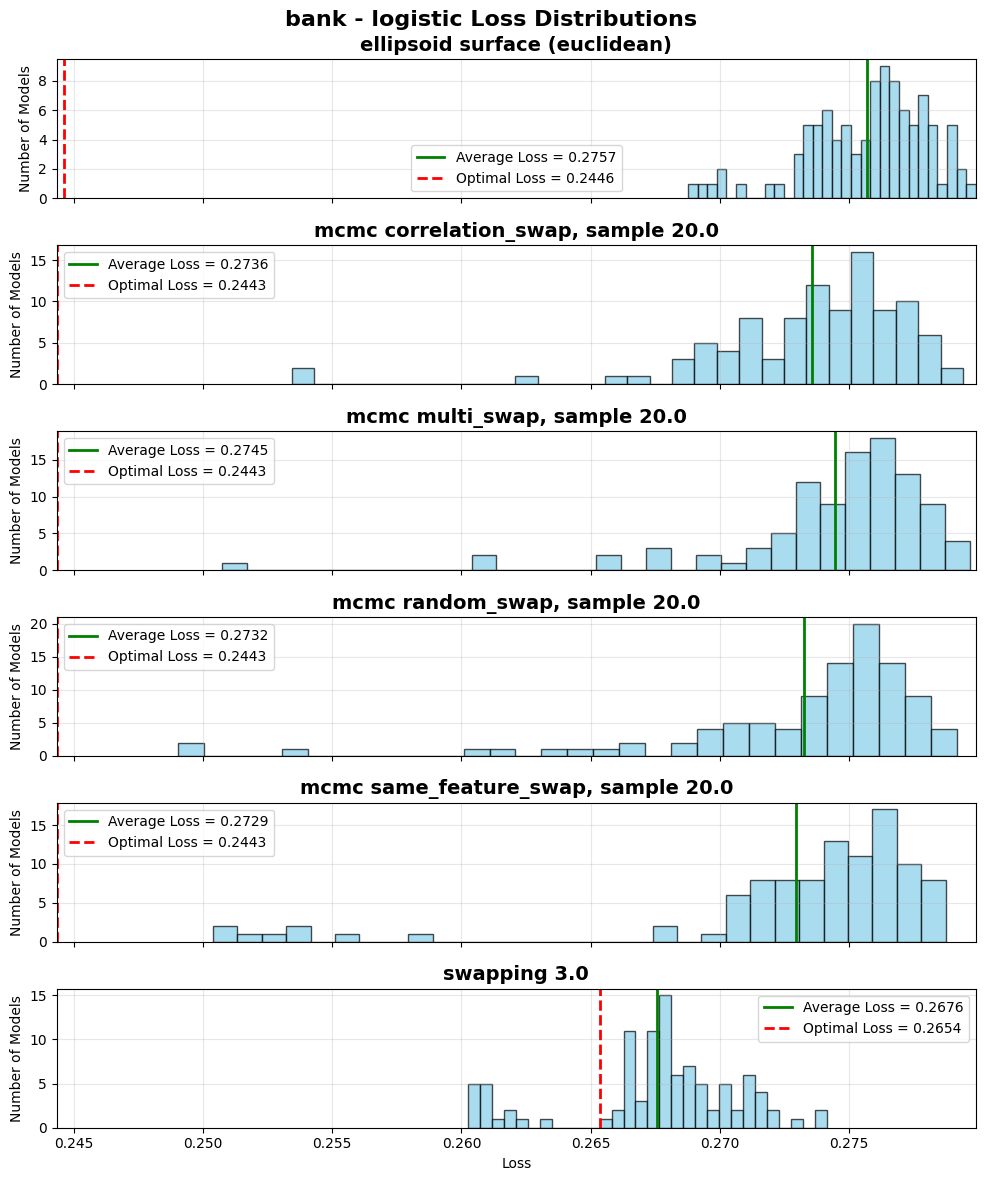

In [12]:
show_loss_distributions(all_datasets_results, "bank", "logistic")

In [6]:
all_datasets_results['bank']

,method_type,dataset,n_estimators,n_support_set,n_samples,w_rset,w_opt,rset_bound,runtime,l0,...,inverse_IoU,euclidean_distance,inverse_cosine_similarity,accuracy,accuracy_opt,logistic,logistic_opt,compute_logit_variance,compute_logit_pairwise_distance,hamming_distance
5,MethodType.ELLIPSOID,bank,50,20,1000,"[[-4.093896494005683, 0.0, 0.0, 0.0, 0.0, 0.0,...","[-0.33499915734294816, 0.0, 0.0, 0.0, 0.0, 0.0...",0.28,8.359598,0.001,...,"(0.0, [0.0, 0.0])","(57.11835437866561, [57.11835437866561, 57.118...","(0.345276069453555, [0.345276069453555, 0.3452...","[0.10019907100199071, 0.0957752709577527, 0.09...",0.096660,"[0.2760424741384634, 0.2799699564486373, 0.275...",0.244636,"(3.042756545907591, [1.5188599515788157, 4.515...","(20.493463450121066, [0.0, 55.14332732418294])","(177.37676767676768, [177.37676767676768, 177...."
13,MethodType.MCMC,bank,50,20,1068,"[[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0...","[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.28,69.500533,0.001,...,"(0.31910076442213814, [0.31910076442213814, 0....","(79.82689572265193, [79.82689572265193, 79.826...","(0.4801726340991423, [0.4801726340991423, 0.48...","[0.10042026100420261, 0.10086264100862641, 0.1...",0.096439,"[0.2711782998355315, 0.26253590346338657, 0.27...",0.244348,"(3.6376423417478407, [1.906477310741829, 6.672...","(23.140290206521865, [4.66675417232035, 57.028...","(196.48161616161616, [196.48161616161616, 196...."
12,MethodType.MCMC,bank,50,20,1067,"[[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0...","[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.28,66.651264,0.001,...,"(0.12648965385957467, [0.12648965385957467, 0....","(85.65840032431062, [85.65840032431062, 85.658...","(0.5305948498142868, [0.5305948498142868, 0.53...","[0.11302809113028091, 0.10528644105286442, 0.1...",0.096439,"[0.2768080871151556, 0.27639890799766814, 0.27...",0.244348,"(3.6130346203721797, [1.7109717276550043, 6.46...","(23.135465480933707, [5.711256053124547, 56.91...","(201.12666666666667, [201.12666666666667, 201...."
14,MethodType.MCMC,bank,50,20,1069,"[[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0...","[-0.3252043396150685, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.28,86.740015,0.001,...,"(0.0013860414848069227, [0.0013860414848069227...","(56.57929622615712, [56.57929622615712, 56.579...","(0.3623682478153525, [0.3623682478153525, 0.36...","[0.1117009511170095, 0.10152621101526212, 0.10...",0.096439,"[0.2772931625245858, 0.25120044603105784, 0.27...",0.244348,"(2.972119426191917, [1.7202951618400502, 4.506...","(20.87788248505989, [4.481673306967602, 52.961...","(186.5, [186.5, 186.5])"
21,MethodType.SWAPPING,bank,50,12,4529,"[[5.958892382275383, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4.677730854475268, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",0.28,262.838621,0.001,...,"(0.039588257613346424, [0.039588257613346424, ...","(11.66240391155663, [11.66240391155663, 11.662...","(0.009139275750564434, [0.009139275750564434, ...","[0.09732360097323602, 0.09643884096438841, 0.0...",0.096660,"[0.2608830502135628, 0.26213972656147694, 0.27...",0.265354,"(2.5560117041453747, [2.3438797698581424, 2.61...","(18.076964882551195, [0.8345272837982612, 52.0...","(71.51454545454546, [71.51454545454546, 71.514..."


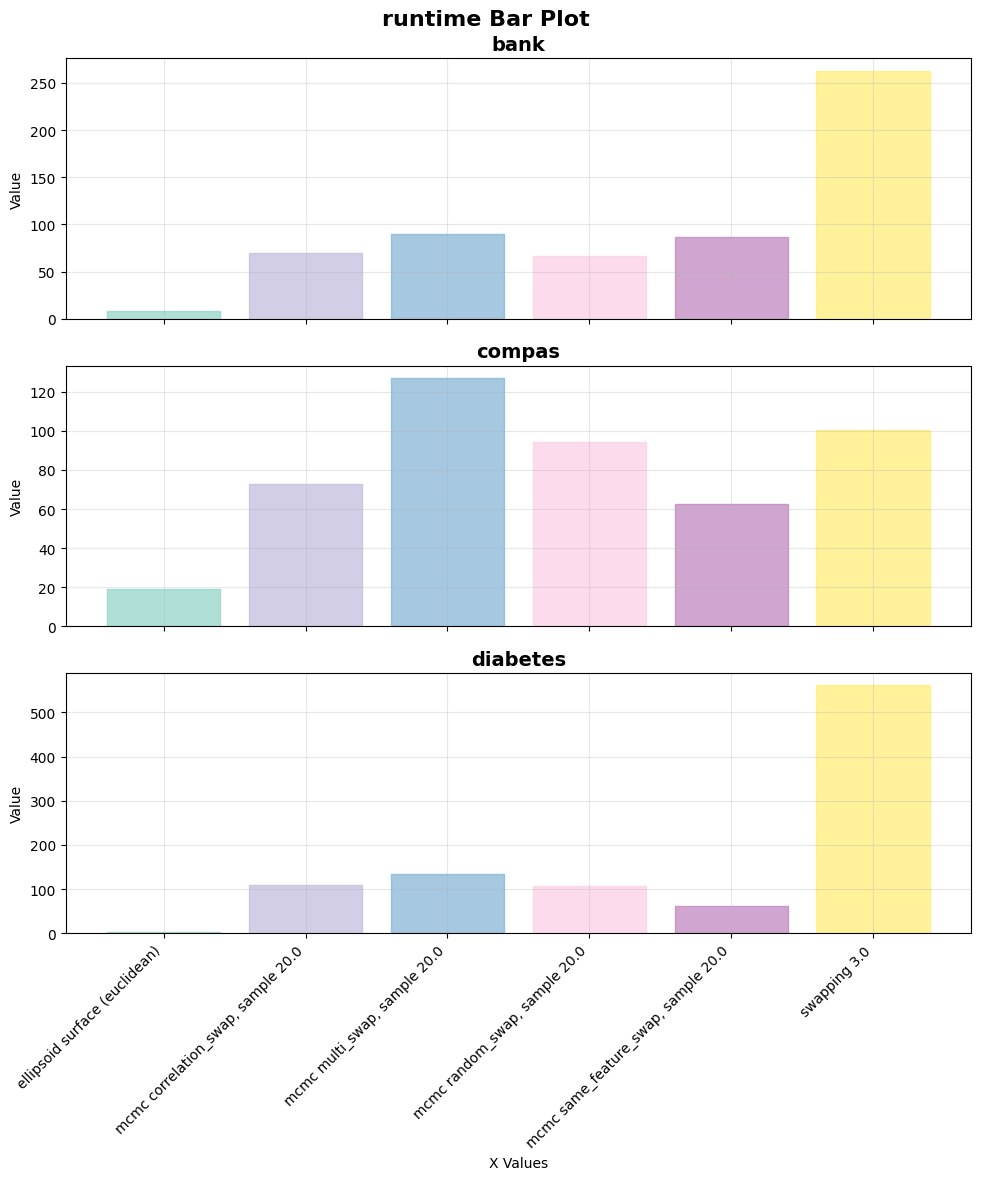

In [23]:
bar_metrics = [
    'runtime'
    'hamming_distance', 
    'inverse_IoU', 
    'euclidean_distance', 
    'inverse_cosine_similarity', 
    'compute_logit_variance', 
    'compute_logit_pairwise_distance'
]
bar_plot = get_bar_plot(all_datasets_results, 'runtime')

loading dataset from ../results/diabetes/l0_0.001_l2_0.001.pkl
loading dataset from ../results/diabetes/l0_0.001_l2_0.001.pkl
loading dataset from ../results/diabetes/l0_0.001_l2_0.001.pkl
loading dataset from ../results/diabetes/l0_0.001_l2_0.001.pkl
loading dataset from ../results/diabetes/l0_0.001_l2_0.001.pkl
loading dataset from ../results/diabetes/l0_0.001_l2_0.001.pkl


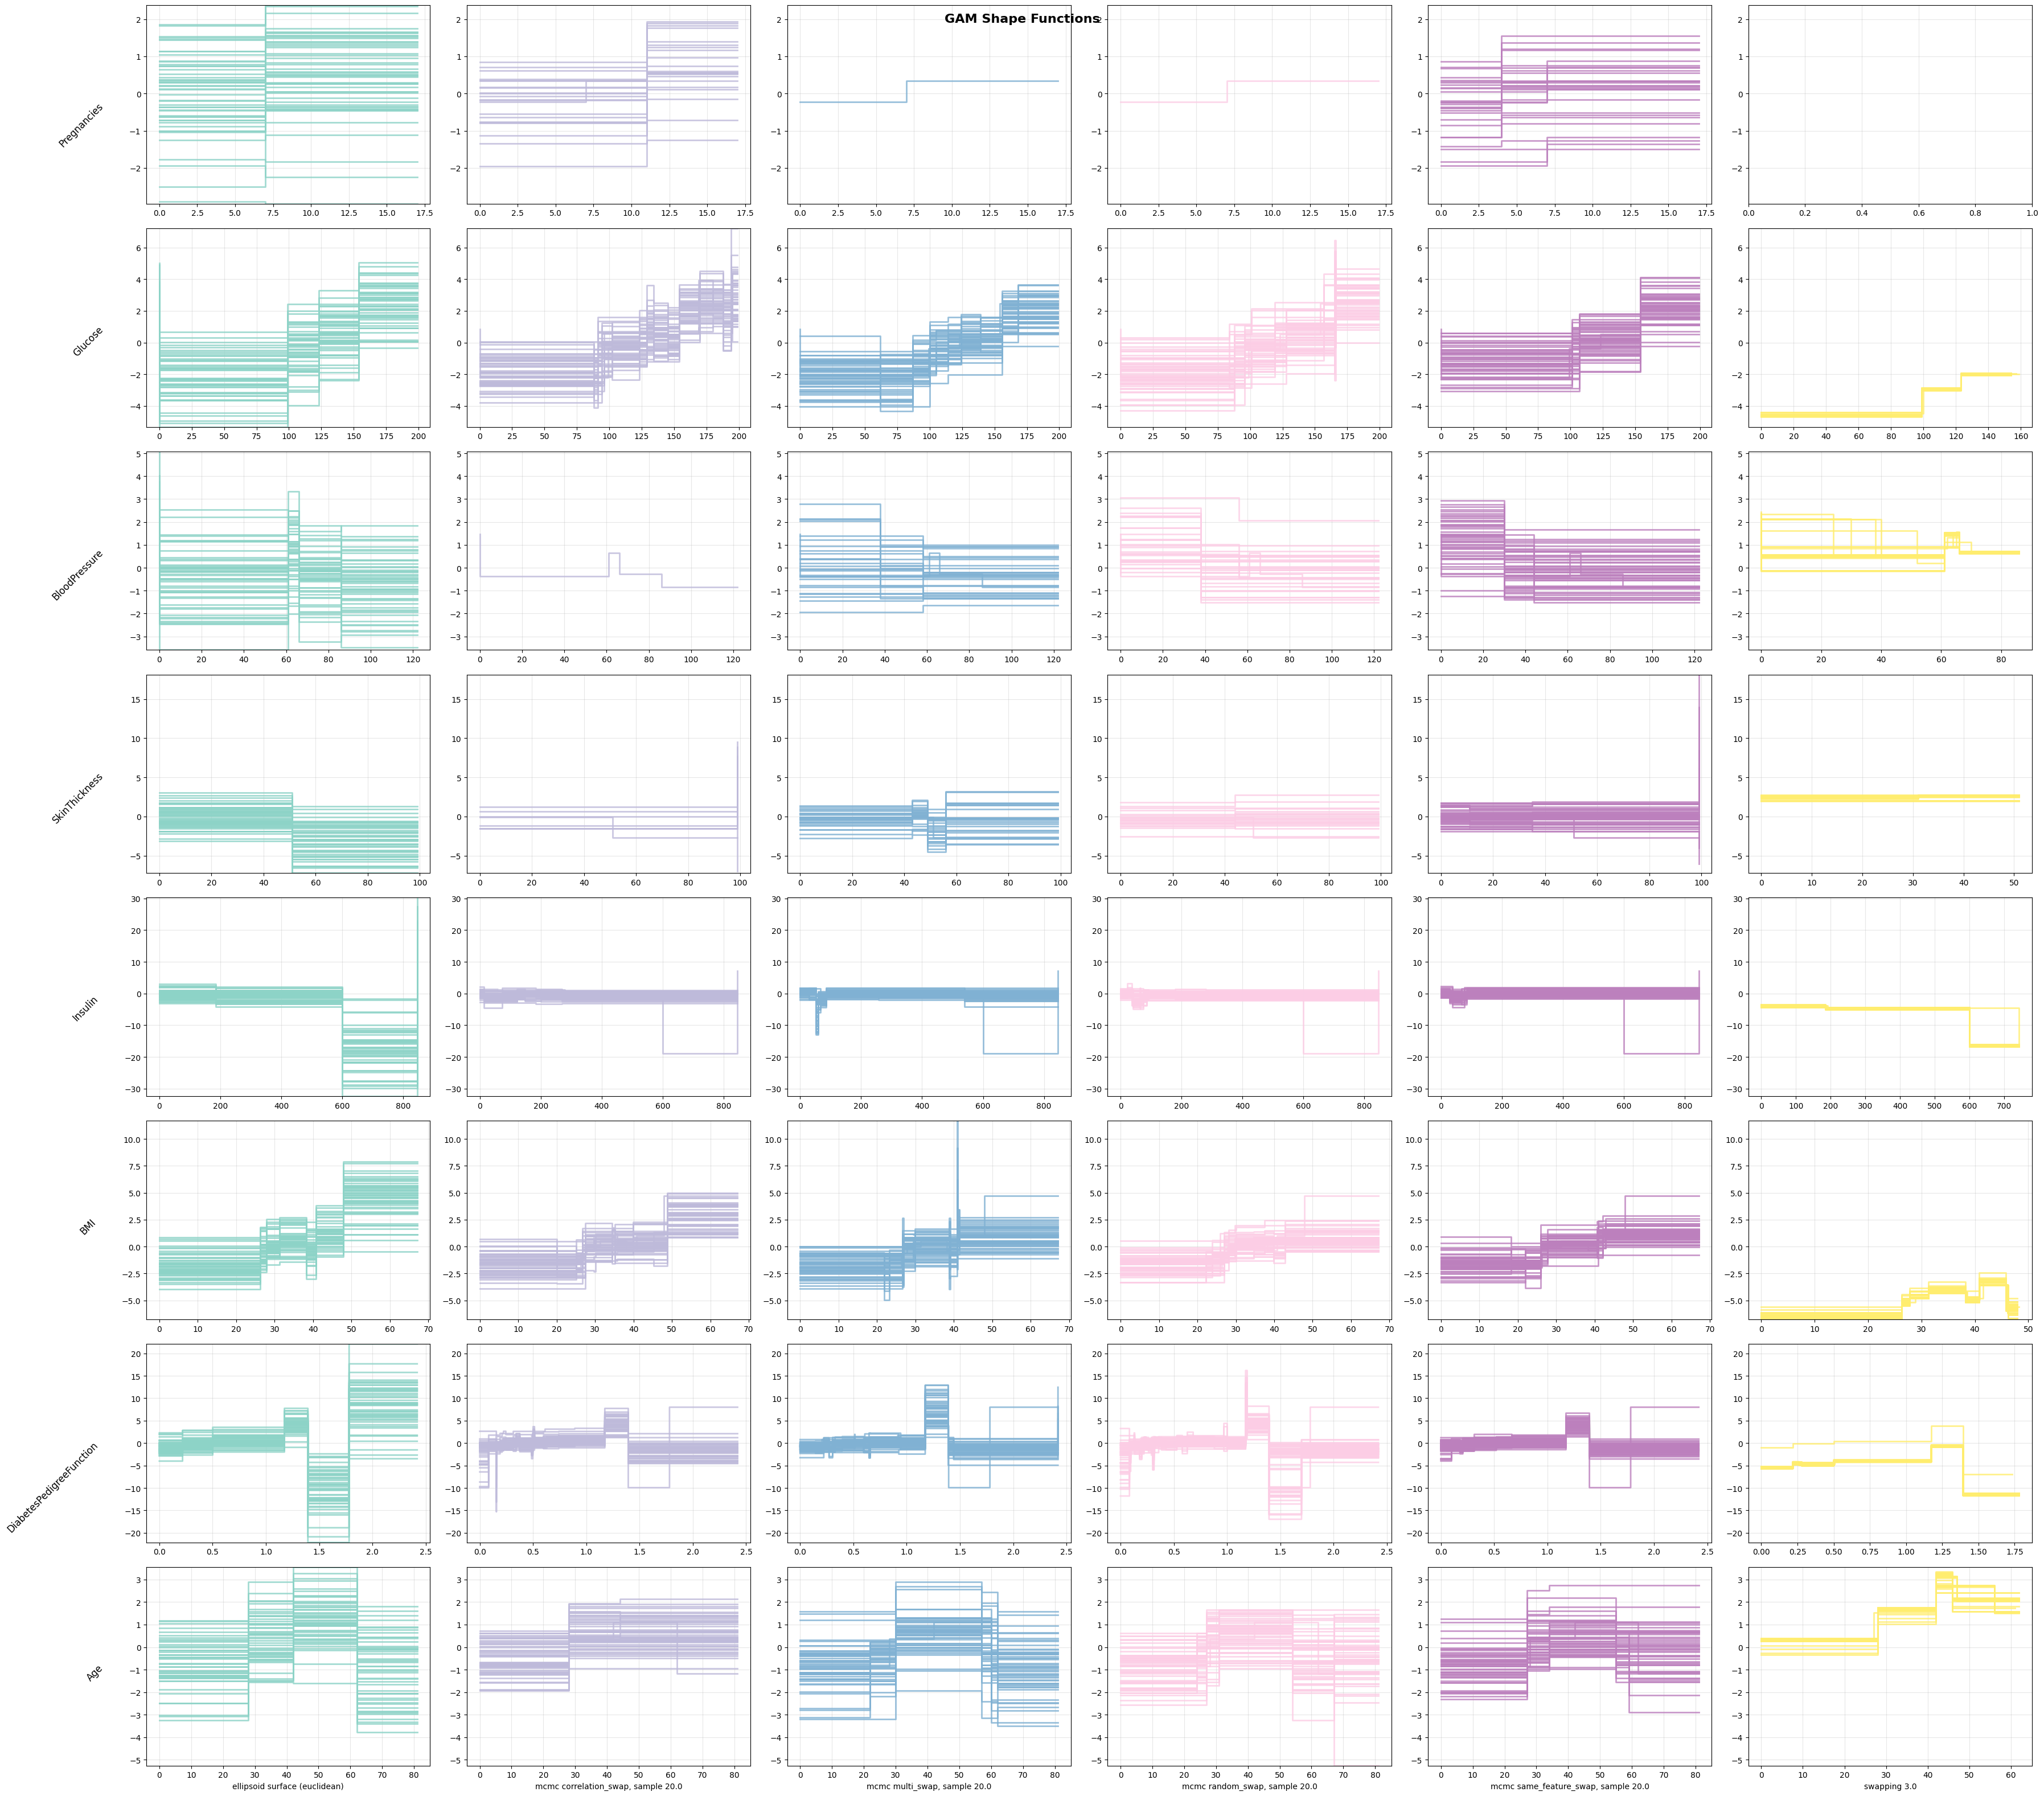

In [13]:
# ["bank", "compas", "diabetes", "spambase", "mimic2"]
gam = get_gam(all_datasets_results, 'diabetes')

In [23]:
variable_importance = get_variable_importance(all_datasets_results, 'bank')

KeyError: 'feature_to_vi'

In [24]:
model_reliance = get_model_reliance(all_datasets_results, "compas")

KeyError: 'feature_to_vi'

In [ ]:
# ['feature_logit_differences', 'feature_shape_differences']
fsd = get_feature_to_shape_diversity(all_datasets_results, "diabetes", "feature_logit_differences")

KeyError: 'feature_logit_differences'

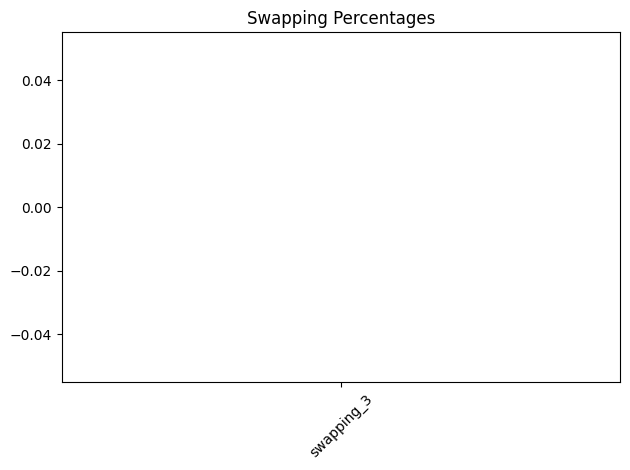

In [ ]:
# show_swapping_percentages(all_datasets_results, "bank")

In [27]:
get_table_results(all_datasets_results)

,dataset,method,runtime,accuracy,logistic,inverse_IoU,euclidean_distance,inverse_cosine_similarity
0,bank,ellipsoid surface (euclidean),8.360,0.101,0.275,0.000,57.118,0.345
1,bank,"mcmc correlation_swap, sample 20.0",69.501,0.103,0.273,0.319,79.827,0.480
2,bank,"mcmc random_swap, sample 20.0",66.651,0.104,0.274,0.126,85.658,0.531
3,bank,"mcmc same_feature_swap, sample 20.0",86.740,0.104,0.273,0.001,56.579,0.362
4,bank,swapping 3.0,262.839,0.097,0.268,0.040,11.662,0.009
5,compas,ellipsoid surface (euclidean),18.980,0.330,0.619,0.000,14.967,0.510
6,compas,"mcmc correlation_swap, sample 20.0",72.751,0.330,0.617,0.042,16.224,0.477
7,compas,"mcmc random_swap, sample 20.0",94.108,0.329,0.617,0.097,18.669,0.513
8,compas,"mcmc same_feature_swap, sample 20.0",62.679,0.324,0.610,0.000,4.752,0.120
9,compas,swapping 3.0,100.491,0.320,0.609,0.061,1.787,0.019


In [ ]:
bar_metrics = ['iou', 'euclidean']
for bm in bar_metrics:
    fig = get_bar_plot(all_datasets_results, bm, methods)  # this should create/return the figure
    fig.savefig(f'figures/{bm}_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for dn in dataset_names:
    fig = get_gam(all_datasets_results, dn)
    fig.savefig(f'figures/{dn}_gam.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for dn in dataset_names[1:]:
    fig = get_model_reliance(all_datasets_results, dn)
    fig.savefig(f'figures/{dn}_model_reliance.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for fsd in feature_to_shape_metrics:
    fig = get_feature_to_shape_diversity(all_datasets_results, dn, fsd)
    fig.savefig(f'figures/{fsd}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)